In [199]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import sys
from pathlib import Path
from scipy.optimize import least_squares
from scipy.signal import butter, sosfiltfilt

if __package__ in {None, ""}:
    sys.path.insert(0, str(Path("../").resolve()))

np.set_printoptions(precision=3, suppress=True)

def print_err_stats(x, gt, center=False, prefix=""):
    if center:
        x = x.copy() - np.mean(x)
        gt = gt.copy() - np.mean(gt)
    error = x - gt
    rmse = np.mean(error ** 2) ** 0.5
    mae = np.mean(abs(error))
    me = np.mean(error)
    print(f"{prefix} RMSE: {rmse:.3f}, MAE: {mae:.3f}, ME: {me:.3f}")
    return rmse, mae, me

In [200]:
from tools.analyze_accel_mismatch import derive_gt


log_filename = "log103"
out_dir = f"../backend/run_artifacts/{log_filename}/cache/"
ws_file = out_dir + "/all.npz"
ws = np.load(ws_file)
print([str(key) for key in ws.keys()])

acc = ws["accel/lpfhp/proj__x"][:, 0]
a_s2_x = ws["accel/lpf/lis2__x"][:, 0]
travel = ws["travel__x"][:, 0]
mag = ws["mag/proj/corr/lpf__x"][:, 0]
mag_raw = ws["mag__x"]
mag_raw_mag = np.linalg.norm(mag_raw, axis=1)
mag_baseline = ws["mag_baseline"][0]
mag_proj_bad_mask = ws["mag/proj/bad_mask__x"][:, 0].astype(bool)
boring_mask = ws["boring_mask"].astype(bool)
#print(acc.shape)
t, a_meas, a_gt, v = derive_gt(ws, use_gradient=True, use_raw=False)
dt_s = np.diff(t, prepend=t[0]-0.01)

print("Mag baseline:", mag_baseline)

def model_pred(mag_i):
    return coeffs[0] * mag_i ** 2 + coeffs[1] * mag_i + coeffs[2]

['__log_config_hash', 'accel/lis1__t', 'accel/lis1__x', 'accel/lis2__t', 'accel/lis2__x', 'gyro/gyro1__t', 'gyro/gyro1__x', 'gyro/gyro2__t', 'gyro/gyro2__x', 'mag__t', 'mag__x', 'mag_lis__t', 'mag_lis__x', 'angle__t', 'angle__x', 'angle/bad_mask__t', 'angle/bad_mask__x', 'gyro/lpf/gyro1__t', 'gyro/lpf/gyro1__x', 'gyro/lpf/gyro2__t', 'gyro/lpf/gyro2__x', 'accel/lpf/lis1__t', 'accel/lpf/lis1__x', 'accel/lpf/lis2__t', 'accel/lpf/lis2__x', 'lis1_chunks_filt', 'lis2_chunks_filt', 'rotation_matrix', 'accel/lis2_in_lis1__t', 'accel/lis2_in_lis1__x', 'accel/relative__t', 'accel/relative__x', 'accel/lpf/relative__t', 'accel/lpf/relative__x', 'accel_trav_vec', 'mags_vs_means', 'accel/proj__t', 'accel/proj__x', 'accel/lpf/proj__t', 'accel/lpf/proj__x', 'accel/lpfhp/proj__t', 'accel/lpfhp/proj__x', 'angle/lpf__t', 'angle/lpf__x', 'travel__t', 'travel__x', 'boring_mask', 'mag/proj__t', 'mag/proj__x', 'mag/lpf__t', 'mag/lpf__x', 'mag_lis/lpf__t', 'mag_lis/lpf__x', 'mag/proj/lpf__t', 'mag/proj/lpf__x

In [201]:
# Try just using S2 to train

hp_fc_hz=1
sos_lp = butter(N=4, Wn=hp_fc_hz, btype="high", fs=100, output="sos")
acc = -sosfiltfilt(sos_lp, a_s2_x)

In [202]:
idx_shift = 1

local_max_indices = (np.diff(np.sign(np.diff(mag))) < 0).nonzero()[0] 
local_min_indices = (np.diff(np.sign(np.diff(mag))) > 0).nonzero()[0]
v0_idxs = np.sort(np.concatenate((local_max_indices, local_min_indices)))
print("v0 indices", v0_idxs.shape)

v0_idxs += idx_shift


v0 indices (13383,)


Local min/max indices: (13383,)
114.0651766181648 9.601668488882751 226.69031843599015
35.49365775089157 1.799256708261396 98.68913492414734
Filtered local min/max indices: 1722
GT velocity at zero v points mean/med/std: 123.96848982759347 62.294613126996865 163.92572792364638
Magnetometer at zero v points mean/med/std: 2293.172321949446 1147.0723935321912 3340.522287070525


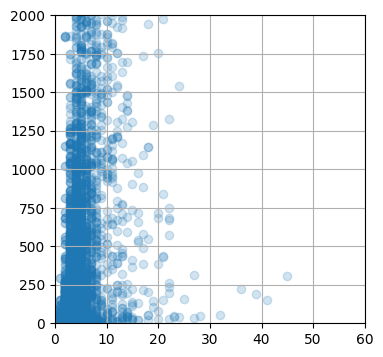

In [203]:
# Filter indices by minimum dt, dmag
abs_v = abs(v)
v_at_indices = abs_v[v0_idxs]
print(f"Local min/max indices: {v0_idxs.shape}")
print(np.mean(abs_v), np.median(abs_v), np.std(abs_v))
print(np.mean(v_at_indices), np.median(v_at_indices), np.std(v_at_indices))

min_dt = 5
min_dm = 50
idxs_filt = []
min_dts = []
min_dms = []
mag_chunks = []
trav_chunks = []
for i in range(1, v0_idxs.shape[0] - 1):
    idx = v0_idxs[i]
    near_idxs = [v0_idxs[i-1], v0_idxs[i+1]]
    mag_i = mag[v0_idxs[i]]
    mag_near = mag[near_idxs]
    min_dm_i = min(abs(mag_near - mag_i))
    min_dt_i = min(abs(near_idxs - idx))
    min_dms.append(min_dm_i)
    min_dts.append(min_dt_i)
    if min_dt_i < min_dt:
        continue
    if min_dm_i < min_dm:
        continue
    idxs_filt.append(idx)
print(f"Filtered local min/max indices: {len(idxs_filt)}")

v_at_indices = abs_v[idxs_filt]
print("GT velocity at zero v points mean/med/std:", np.mean(v_at_indices), np.median(v_at_indices), np.std(v_at_indices))
mag_at_indices = mag[idxs_filt]
print("Magnetometer at zero v points mean/med/std:", np.mean(mag_at_indices), np.median(mag_at_indices), np.std(mag_at_indices))

plt.figure(figsize=(4, 4))
plt.scatter(min_dts, min_dms, alpha=0.2)
plt.ylim((0, 2000))
plt.xlim((0, 60))
plt.grid()


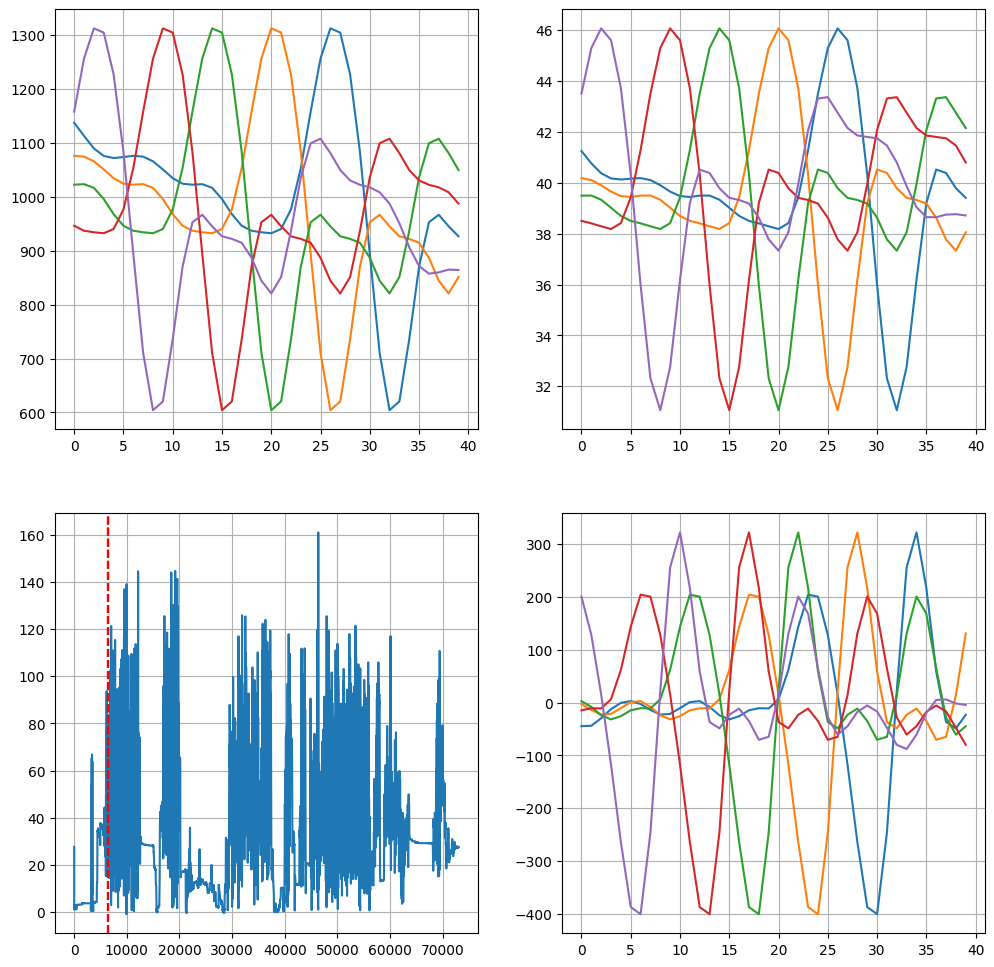

In [204]:
# Chunkify and visualize travel, velocity, and mag
def get_chunks(idxes, width=20):
    mag_chunks = []
    trav_chunks = []
    v_chunks = []
    for idx in idxes:
        mag_chunks.append(mag[idx - width:idx + width])
        trav_chunks.append(travel[idx - width:idx + width])
        v_chunks.append(v[idx - width:idx + width])
    return mag_chunks, trav_chunks, v_chunks

roi_start = 20
roi_len = 5
plt.figure(figsize=(12, 12))
mag_chunks, trav_chunks, v_chunks = get_chunks(idxs_filt[roi_start:roi_start + roi_len])
plt.subplot(2, 2, 1)
for i in range(len(mag_chunks)):
    plt.plot(mag_chunks[i])
plt.grid()
plt.subplot(2, 2, 2)
for i in range(len(trav_chunks)):
    plt.plot(trav_chunks[i])
plt.grid()
plt.subplot(2, 2, 4)
for i in range(len(v_chunks)):
    plt.plot(v_chunks[i])
plt.grid()
plt.subplot(2, 2, 3)
plt.plot(travel)
for idx in idxs_filt[roi_start:roi_start + roi_len]:
    plt.axvline(x=idx, color='r', linestyle='--')
plt.grid()

In [205]:
# Create chunks for training
min_dx = 10
max_dx = 1500
chunk_len = 20
min_mag = mag_baseline # max(700, mag_baseline)

#acc -= np.mean(acc)
def get_chunk_conf(mag_chunk: np.ndarray, dx_chunk: np.ndarray):
    l_slice = slice(0, chunk_len)
    r_slice = slice(chunk_len, chunk_len * 2 - 1)
    dx_l = dx_chunk[l_slice]
    dx_r = dx_chunk[r_slice]
    print(dx_chunk.shape, dx_l.shape, dx_r.shape)
    print(dx_chunk)
    print(dx_l)
    print(dx_r)
    if max(np.abs(dx_l)) > max(np.abs(dx_r)):
        src_slice = l_slice
        test_slice = r_slice
    else:
        src_slice = l_slice
        test_slice = r_slice
    print("Source dx, mag", dx_chunk[src_slice], mag_chunk[src_slice])

    xp = dx_chunk[src_slice]
    fp = mag_chunk[src_slice]

    fp = fp[xp.argsort()]
    xp.sort()

    x = dx_chunk[test_slice]

    print(x.shape, xp.shape, fp.shape)

    interp_mag = np.interp(x=x, xp=xp, fp=fp)
    test_mag = mag_chunk[test_slice]
    print(x)
    print(interp_mag)
    print(test_mag)

errs = []
xs = []
travs = []
mags = []
a_chunks = []
slices = []
dm_dxs = []
filts = {
    "bad": 0,
    "dm_dx": 0,
    "mag": 0,
    "dx": 0
}
for idx in idxs_filt:
    if idx < chunk_len or idx + chunk_len >= len(mag):
        continue
    #dt_chunk = dt_s[idx - chunk_len:idx + chunk_len]
    t_chunk = t[idx - chunk_len:idx + chunk_len]
    a_chunk = acc[idx - chunk_len:idx + chunk_len] * 1000
    badmask_chunk = mag_proj_bad_mask[idx - chunk_len:idx + chunk_len]
    if np.mean(badmask_chunk) > 0.5:
        filts["bad"] += 1
        continue
    #v_chunk = np.cumsum(a_chunk * dt_chunk)
    v_chunk = scipy.integrate.cumulative_trapezoid(a_chunk, t_chunk, initial=0)
    v_chunk -= v_chunk[chunk_len]
    dx_chunk = v_chunk# * dt_chunk
    #x_chunk = np.cumsum((v_chunk) * dt_chunk)
    x_chunk = scipy.integrate.cumulative_trapezoid(v_chunk, t_chunk, initial=0)
    x_chunk -= x_chunk[chunk_len]
    if (max(x_chunk) - min(x_chunk) < min_dx) or (max(x_chunk) - min(x_chunk) > max_dx):
        filts["dx"] += 1
        continue
    mag_chunk = mag[idx - chunk_len:idx + chunk_len]
    if np.min(mag_chunk) < min_mag:
        filts["mag"] += 1
        continue

    trav_chunk = travel[idx - chunk_len:idx + chunk_len]
    dm_chunk = np.diff(mag_chunk, prepend=mag_chunk[0])
    dm_dx = dm_chunk / (dx_chunk + 1e-6)
    if np.median(dm_dx) < 0.05:
        filts["dm_dx"] += 1
        continue

    #get_chunk_conf(mag_chunk, x_chunk)
    #break
                                                        
    errs.append(x_chunk - trav_chunk + travel[idx])
    xs.append(x_chunk)
    travs.append(trav_chunk)
    mags.append(mag_chunk)
    a_chunks.append(a_chunk)
    slices.append(slice(idx - chunk_len, idx + chunk_len))
    dm_dxs.append(dm_dx)
print(len(errs), " chunks for training")
print(filts)

312  chunks for training
{'bad': 0, 'dm_dx': 56, 'mag': 1344, 'dx': 10}


1722 (312, 40)
Filtered {'bad': 0, 'dm_dx': 56, 'mag': 1344, 'dx': 10}
Num over s2 cap: 49 / 312
Median max s2: 58.6 mean: 64.1
Mean travel: 70.0
Mean mag: 3312.1
Mean abs error: 15.7

Mag to err corr: 0.152
Dtrav to err corr: 0.443
Max s2 to err corr: 0.451
Max s2 to dtrav corr: 0.596
X max to err corr: 0.745
X median to err corr: 0.855
Point X to err corr: 0.832
Point X to prop err corr: 0.786
Mean error at X 13.5: 4.010
Mean error at X 32.0: 6.113
Mean error at X 60.4: 5.158
Mean error at X 80.3: 8.964
Mean error at X 128.6: 23.290
Center offset -1 v abs median 59.6 mean 100.6
Center offset 0 v abs median 50.3 mean 87.7
Center offset 1 v abs median 151.7 mean 214.1


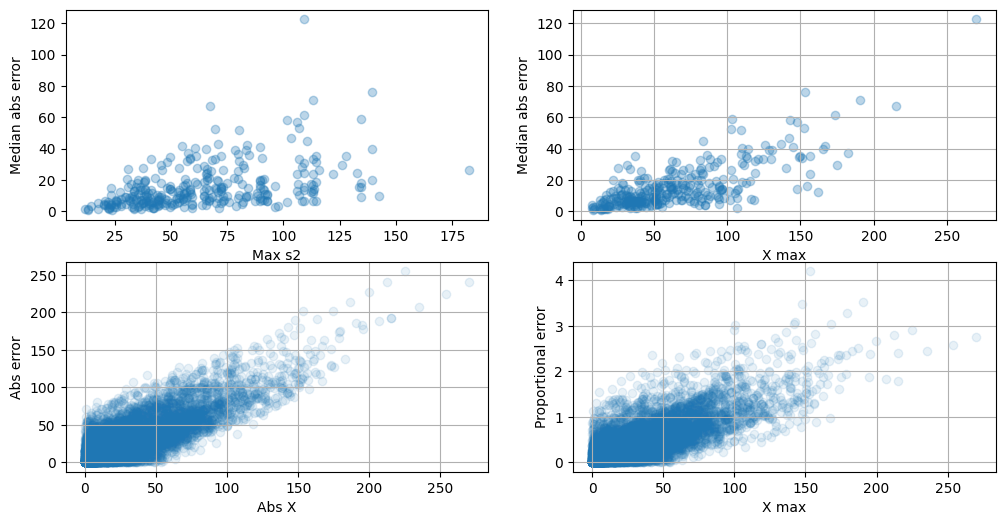

In [206]:
max_s2s = np.asarray([np.max(np.abs(a_s2_x[slice_i])) for slice_i in slices])
trav_meds = np.median(np.asarray(travs), axis=1)
dtravs = np.max(travs, axis=1) - np.min(travs, axis=1)
mag_meds = np.median(np.asarray(mags), axis=1)
absx_meds = np.median(np.abs(np.asarray(xs)), axis=1)
absx_maxs = np.max(np.abs(np.asarray(xs)), axis=1)

err_arr = np.array(errs)
abs_err_arr = np.abs(err_arr)
mae = np.median(abs_err_arr, axis=0)
me = np.median(err_arr, axis=0)
med_abs_x = np.median(np.abs(xs), axis=0)
med_x = np.median(xs, axis=0)
err_meds = np.median(abs_err_arr, axis=1)

abs_x_flat = np.abs(np.asarray(xs)).flatten()
err_flat = err_arr.flatten()
abs_err_flat = abs_err_arr.flatten()
trav_flat = np.asarray(travs).flatten()

print(len(idxs_filt), err_arr.shape)
print("Filtered", filts)

s2_over_cap = max_s2s > 100
print(f"Num over s2 cap: {np.sum(s2_over_cap)} / {len(max_s2s)}")

print(f"Median max s2: {np.median(max_s2s):.1f} mean: {np.mean(max_s2s):.1f}")
print(f"Mean travel: {np.mean(trav_meds):.1f}")
print(f"Mean mag: {np.mean(mag_meds):.1f}")
print(f"Mean abs error: {np.mean(err_meds):.1f}")
print()
print(f"Mag to err corr: {np.corrcoef(mag_meds, err_meds)[0, 1]:.3f}")
print(f"Dtrav to err corr: {np.corrcoef(dtravs, err_meds)[0, 1]:.3f}")
print(f"Max s2 to err corr: {np.corrcoef(max_s2s, err_meds)[0, 1]:.3f}")
print(f"Max s2 to dtrav corr: {np.corrcoef(max_s2s, dtravs)[0, 1]:.3f}")
print(f"X max to err corr: {np.corrcoef(absx_maxs, err_meds)[0, 1]:.3f}")
print(f"X median to err corr: {np.corrcoef(absx_meds, err_meds)[0, 1]:.3f}")
print(f"Point X to err corr: {np.corrcoef(abs_x_flat, abs_err_flat)[0, 1]:.3f}")


plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.scatter(max_s2s, err_meds, alpha=0.3)
plt.xlabel("Max s2")
plt.ylabel("Median abs error")
plt.subplot(2, 2, 2)
plt.scatter(absx_maxs, err_meds, alpha=0.3)
plt.xlabel("X max")
plt.ylabel("Median abs error")
plt.grid()
plt.subplot(2, 2, 3)
plt.scatter(abs_x_flat, abs_err_flat, alpha=0.1)
plt.xlabel("Abs X")
plt.ylabel("Abs error")
plt.grid()
plt.subplot(2, 2, 4)

at_flat = np.abs(trav_flat)
trav_mask_i = at_flat > 10
prop_err = abs_err_flat[trav_mask_i] / at_flat[trav_mask_i]
ax_filt = abs_x_flat[trav_mask_i]
print(f"Point X to prop err corr: {np.corrcoef(ax_filt, prop_err)[0, 1]:.3f}")

for p in np.percentile(abs_x_flat, [50, 75, 90, 95, 99]):
    mask_i = abs_x_flat > p
    mean_err_p = np.mean(err_flat[mask_i])
    print(f"Mean error at X {p:.1f}: {mean_err_p:.3f}")

plt.scatter(ax_filt, prop_err, alpha=0.1)
plt.xlabel("X max")
plt.ylabel("Proportional error")
plt.grid()

for offset in range(-1, 2):
    vs = np.array([np.abs(v[slice_i][chunk_len + offset]) for slice_i in slices])
    print(f"Center offset {offset} v abs median {np.median(vs):.1f} mean {np.mean(vs):.1f}")

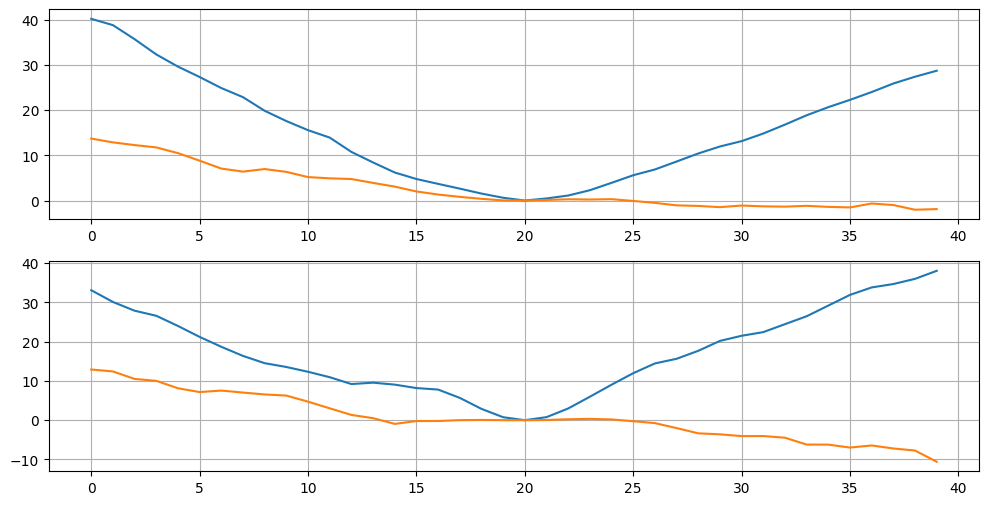

In [207]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(mae)
plt.plot(me)
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(med_abs_x)
plt.plot(med_x)
plt.grid()

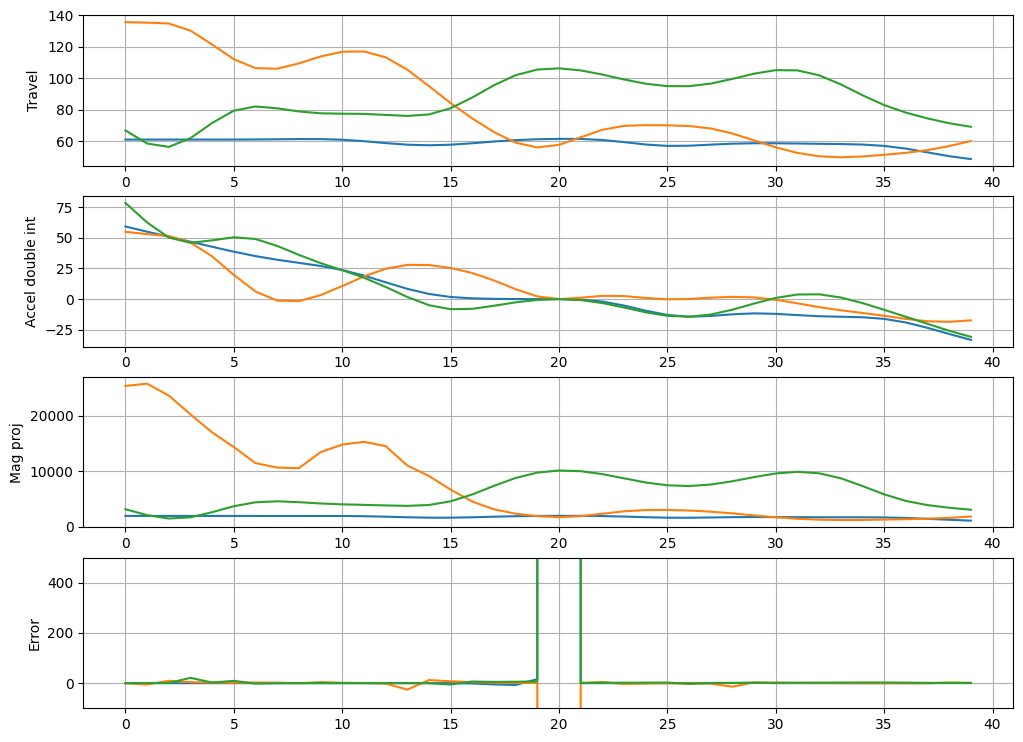

In [208]:
# Plot a few interesting chunks
mid_err = int(len(err_meds) / 2)
worst_idxs = np.argsort(err_meds)[mid_err:mid_err+3]
best_idxs = np.argsort(err_meds)[:5]

plt.figure(figsize=(12, 9))
plt.subplot(4, 1, 1)
for idx in worst_idxs:
    #plt.plot(a_chunks[worst_idxs[i]])
    plt.plot(travs[idx])
plt.ylabel("Travel")
plt.grid()

plt.subplot(4, 1, 2)
for idx in worst_idxs:
    plt.plot(xs[idx])
    #slice_idx = slices[idx]
    #print(slice_idx)
    #plt.plot(lis1_lpf_x[slice_idx])
plt.ylabel("Accel double int")
plt.grid()

plt.subplot(4, 1, 3)
for idx in worst_idxs:
    plt.plot(mags[idx])
    #slice_idx = slices[idx]
    #print(slice_idx)
    #plt.plot(lis1_lpf_x[slice_idx])
plt.ylabel("Mag proj")
plt.grid()

plt.subplot(4, 1, 4)
for idx in worst_idxs:
    plt.plot(dm_dxs[idx])
    #plt.plot(xs[idx] - travs[idx] + travs[idx][chunk_len])
plt.ylim((-100, 500))
plt.ylabel("Error")
plt.grid()


slice(np.int64(66952), np.int64(67032), None)
slice(np.int64(19046), np.int64(19126), None)
slice(np.int64(73602), np.int64(73682), None)


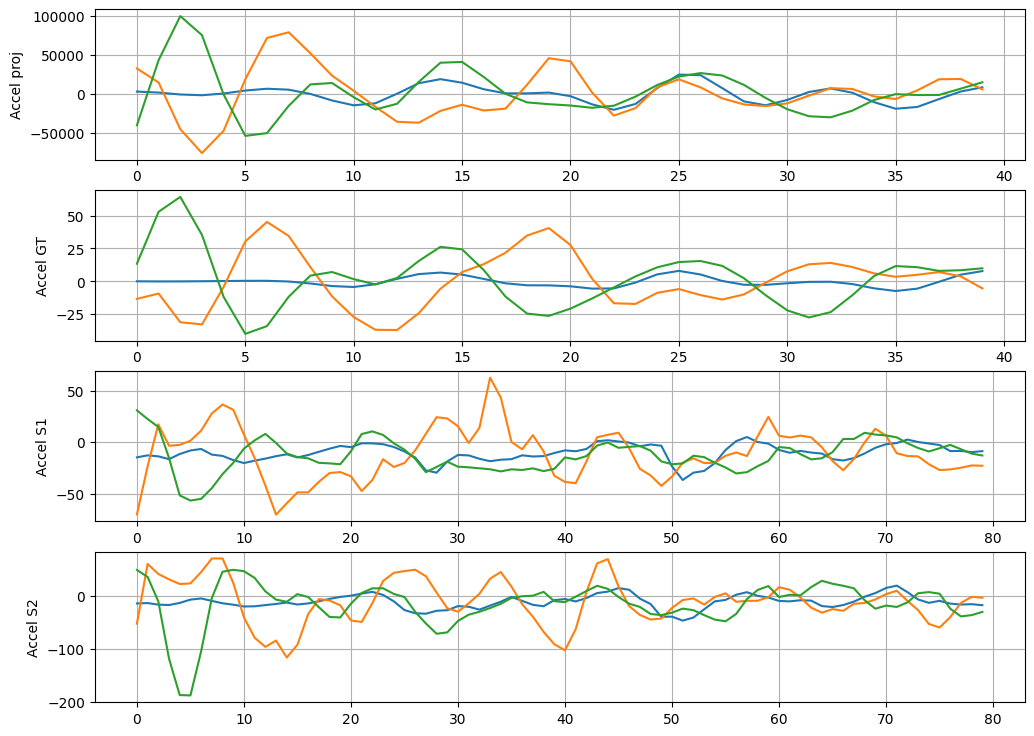

In [209]:
# More plots of interesting chunks
plt.figure(figsize=(12, 9))
lis1_lpf_x = ws["accel/lpf/lis1__x"][:, 0]
lis2_lpf_x = ws["accel/lpf/lis2__x"][:, 0]
lis1_x = ws["accel/lis1__x"][:, 0]
lis2_x = ws["accel/lis2__x"][:, 0]

def get_raw_slice(x): return slice(x.start * 2, x.stop * 2)

plt.subplot(4, 1, 1)
for idx in worst_idxs:
    plt.plot(a_chunks[idx])
    #slice_idx = slices[idx]
    #plt.plot(lis2_lpf_x[slice_idx])
plt.ylabel("Accel proj")
plt.grid()

plt.subplot(4, 1, 2)
for idx in worst_idxs:
    plt.plot(a_gt[slices[idx]])
    #slice_idx = slices[idx]
    #plt.plot(lis2_lpf_x[slice_idx])
plt.ylabel("Accel GT")
plt.grid()

plt.subplot(4, 1, 3)
for idx in worst_idxs:
    slice_idx = get_raw_slice(slices[idx])
    plt.plot(lis1_x[slice_idx])
    print(slice_idx)
plt.ylabel("Accel S1")
plt.grid()

plt.subplot(4, 1, 4)
for idx in worst_idxs:
    slice_idx = get_raw_slice(slices[idx])
    plt.plot(lis2_x[slice_idx])
plt.ylabel("Accel S2")
plt.grid()

In [210]:
# Formulate input data and residuals
# Axis 0: chunk: n_chunks
# Axis 1: point index: n_points
# Axis 2: mag (absolute), x (relative to point at index 0): 

pt_idxes = [chunk_len] + list(range(0, chunk_len)) + list(range(chunk_len + 1, 2 * chunk_len))

gt_list = []
input_list = []
for i, (x_i, mag_i, trav_i) in enumerate(zip(xs, mags, travs)):
    input_list.append([mag_i[pt_idxes], x_i[pt_idxes]])
    gt_list.append(trav_i[pt_idxes])

input_arr = np.array(input_list)
print("Min mag at indices:", np.min(input_arr[:, 0, :]), "mean", np.mean(input_arr[:, 0, :]), "max", np.max(input_arr[:, 0, :]))
print(input_arr.shape)

Min mag at indices: 668.1491104012421 mean 3512.5388101032754 max 25765.581534658104
(312, 2, 40)


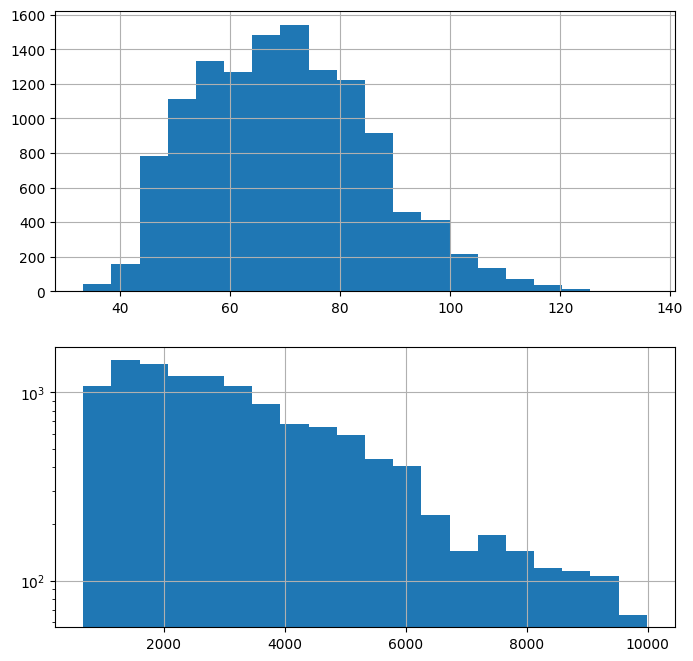

In [211]:
# Plot histogram of ground truth travel in chunks

gt_arr = np.array(gt_list)
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.hist(gt_arr.flatten(), bins=20)
plt.grid()

mag_arr = np.array(mags)
plt.subplot(2, 1, 2)
plt.hist(mag_arr[mag_arr < 10000].flatten(), bins=20)
plt.semilogy()
plt.grid()

In [212]:
# def pred_x(mag_i, x0, y_scale, power, y0=0, m=0):
#     mag_i = np.copy(mag_i)
#     mag_i[(mag_i - x0) < 0] = x0
#     return ((mag_i - x0) ** power) * abs(y_scale) + (abs(m) * (mag_i - x0)) + y0
pred_soft_mg: float = 50.0

def pred_x(mag_i, x0, y_scale, power, y0=0):
    dx = np.asarray(mag_i, dtype=float) - x0
    soft = (np.abs(dx) + pred_soft_mg) ** power - (pred_soft_mg ** power)
    return np.sign(dx) * soft * y_scale + y0

power_prior = 1/3
power_weight = 1000
dx_thresh = 1000

def get_err_mask(dx, dx_thresh):
    return np.abs(dx) < dx_thresh

def calculate_res(vec):
    x0, y_scale, power = vec[0], vec[1], vec[2]

    zero_x_mags = input_arr[:, 0, 0]
    zero_x_preds = pred_x(zero_x_mags, x0, y_scale, power=power)
    x_pts = input_arr[:, 1, 1:]
    x_acc_preds = x_pts + zero_x_preds[:, np.newaxis]

    mag_pts = input_arr[:, 0, 1:]
    x_mag_preds = pred_x(mag_pts, x0, y_scale, power=power)

    res = x_acc_preds - x_mag_preds
    res = res * get_err_mask(x_pts, dx_thresh)

    power_res = power - power_prior

    return np.concatenate([res.flatten(), np.array([power_res]) * power_weight])

guess_vec = [mag_baseline, 3, 1/3]
res = calculate_res(guess_vec)
print("Res shape:", res.shape)

Res shape: (12169,)


In [213]:
result = least_squares(
                fun=calculate_res,
                x0=guess_vec, 
                method="trf",
                verbose=1,
                max_nfev=1000,
                #loss='huber',
            )

print("x0, y_scale, power:", result.x)

`ftol` termination condition is satisfied.
Function evaluations 14, initial cost 6.9462e+06, final cost 6.9303e+06, first-order optimality 6.06e+01.
x0, y_scale, power: [246.138   5.64    0.295]


Zero mag -705.4 pred: -25.4
33845 (72985,)
Error mask ratio 0.5755292183325341
Mag-predicted x (not centered) RMSE: 29.093, MAE: 28.562, ME: -28.562
Mag-predicted x RMSE: 5.533, MAE: 4.218, ME: -0.000
Mag-predicted x (thresholded at -1200.0 mG) RMSE: 4.969, MAE: 3.701, ME: -0.000


(np.float64(4.969358852941928),
 np.float64(3.7009190575234525),
 np.float64(-8.760386254335193e-15))

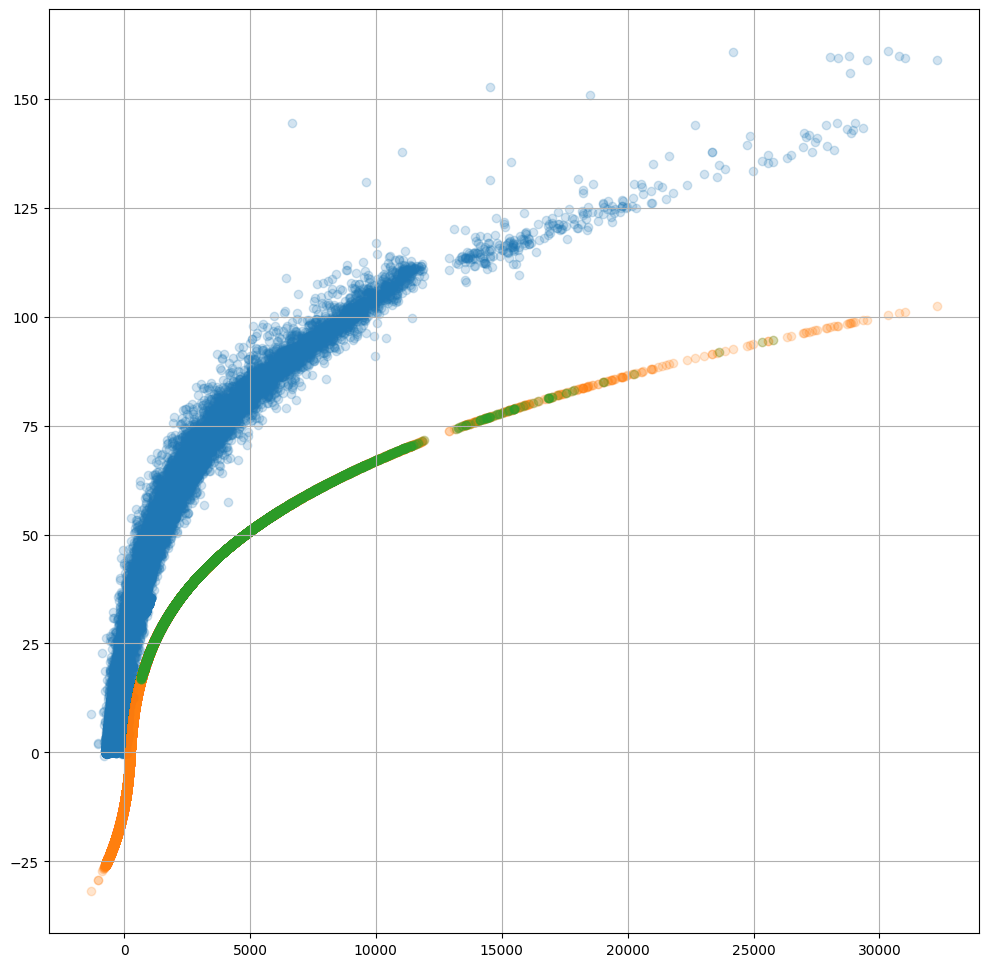

In [214]:
# Calc RMSE
good_mag_mask = np.ones_like(mag_proj_bad_mask)#~mag_proj_bad_mask
mags_flat = mag[good_mag_mask].flatten().copy() #input_arr[:, 0, :].flatten()
x_mag_flat = pred_x(mags_flat, result.x[0], result.x[1], result.x[2])

trav_flat = travel[good_mag_mask].flatten().copy() #np.array(gt_list).flatten()
thresh = -1200#mag_baseline
#mag_thresh_mask = (mag > thresh) & boring_mask
mag_thresh_mask = (trav_flat > 30) & boring_mask
trav_offset = np.mean(trav_flat)

mag_pts = input_arr[:, 0, 1:]
mag_pts_preds = pred_x(mag_pts, result.x[0], result.x[1], power=result.x[2])
#mag_pts_preds -= np.mean(mag_pts_preds)
#trav_flat -= trav_offset
#x_mag_flat -= np.mean(x_mag_flat)
zero_mag = np.percentile(mag, 0.5)
zero_mag_pred = pred_x(zero_mag, result.x[0], result.x[1], result.x[2])
print(f"Zero mag {zero_mag:.1f} pred: {zero_mag_pred:.1f}")
#x_mag_flat -= zero_mag_pred

print(np.sum(mag_thresh_mask), mag_thresh_mask.shape)
print("Error mask ratio", np.sum(boring_mask) / len(boring_mask))

plt.figure(figsize=(12, 12))
plt.scatter(mags_flat, trav_flat, alpha=0.2, label="ground truth travel")
plt.scatter(mags_flat, x_mag_flat, alpha=0.2, label="predicted travel")
plt.scatter(mag_pts.flatten(), mag_pts_preds.flatten(), alpha=0.2, label="predicted travel at points")
plt.grid()

print_err_stats(x_mag_flat[boring_mask], trav_flat[boring_mask], prefix="Mag-predicted x (not centered)", center=False)
print_err_stats(x_mag_flat[boring_mask], trav_flat[boring_mask], prefix="Mag-predicted x", center=True)
print_err_stats(x_mag_flat[mag_thresh_mask], trav_flat[mag_thresh_mask], prefix="Mag-predicted x (thresholded at {:.1f} mG)".format(thresh), center=True)

(72985,) (72985,) (72985,)
-1308.5376815956758 32269.76864711518


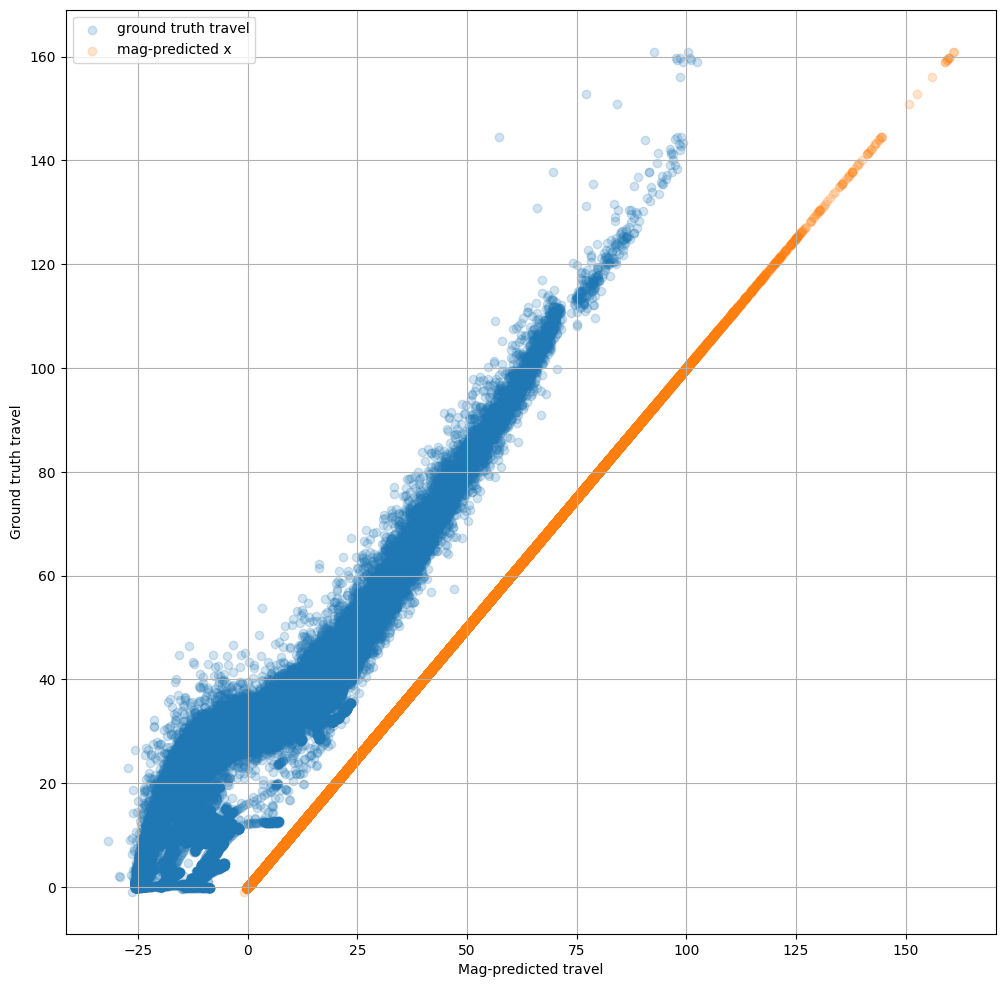

In [215]:
# Another plot of predicted vs actual travel, colored by mag value
# zero_x_mags = input_arr[:, 0, 0]
# zero_x_preds = pred_x(zero_x_mags, result.x[0], result.x[1], result.x[2])
# print(zero_x_preds.shape)
# x_acc_pred = input_arr[:, 1, :] + zero_x_preds[:, np.newaxis] - np.mean(zero_x_preds)
# print_err_stats(x_acc_pred.flatten(), trav_flat, prefix="Accel-predicted x")

print(mags_flat.shape, x_mag_flat.shape, trav_flat.shape)
print(min(mags_flat), max(mags_flat))

plt.figure(figsize=(12, 12))
#plt.subplot(2, 1, 1)
plt.scatter(x_mag_flat, trav_flat, alpha=0.2, label="ground truth travel")
plt.scatter(trav_flat, trav_flat, alpha=0.2, label="mag-predicted x")
plt.xlabel("Mag-predicted travel")
plt.ylabel("Ground truth travel")
plt.legend()
#plt.ylim(-50, 200)
plt.grid()

# plt.subplot(2, 1, 2)
# plt.scatter(mags_flat, trav_flat, alpha=0.2, label="ground truth travel")
# plt.scatter(mags_flat, x_acc_pred.flatten(), alpha=0.5, label="accel-predicted x")
# plt.legend()
# plt.ylim(-50, 100)
# plt.grid()
# plt.show()

`ftol` termination condition is satisfied.
Function evaluations 39, initial cost 1.0672e+07, final cost 1.0275e+05, first-order optimality 1.46e+00.
[-186.654   18.476    0.226   -0.607]
Mag-predicted x RMSE: 2.769, MAE: 1.911, ME: -0.000


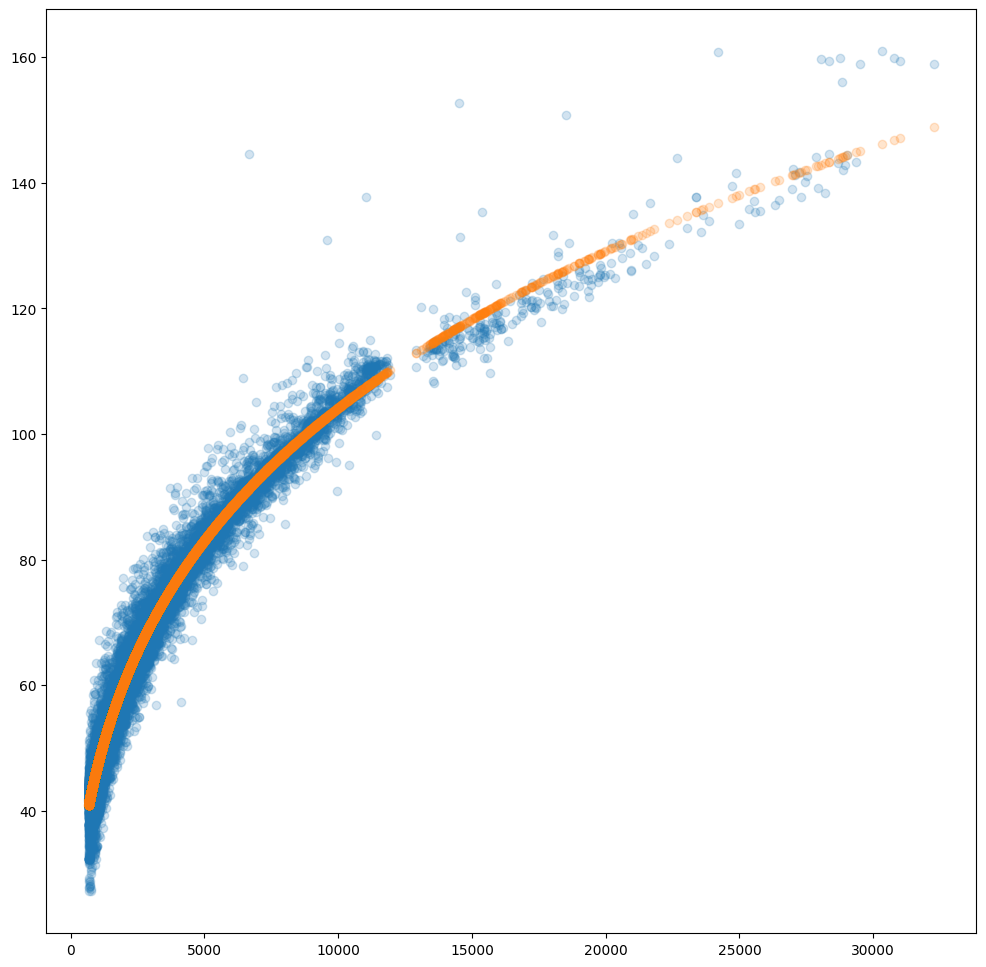

In [216]:
train_mask = (mag > mag_baseline) & boring_mask
def gt_res(vec):
    x0, y_scale, power, y0 = vec[0], vec[1], vec[2], vec[3]
    return pred_x(mag[train_mask], x0, y_scale, power=power, y0=y0) - travel[train_mask]


#guess_vec = [mag_baseline, 2, 1/3, 3, 1]
guess_vec = [result.x[0], result.x[1], result.x[2], 0]
gt_result = least_squares(
                fun=gt_res,
                x0=guess_vec, 
                method="trf",
                verbose=1,
                max_nfev=1000,
                #loss='huber',
            )

mask = good_mag_mask & train_mask
mag_i = mag[mask]
trav_i = travel[mask]

gt_coeffs = gt_result.x
print(gt_coeffs)
gt_preds = pred_x(mag_i, gt_coeffs[0], gt_coeffs[1], gt_coeffs[2], gt_coeffs[3])

print_err_stats(gt_preds, trav_i, prefix="Mag-predicted x", center=False)

plt.figure(figsize=(12, 12))
plt.scatter(mag_i, trav_i, alpha=0.2, label="ground truth travel")
plt.scatter(mag_i, gt_preds, alpha=0.2, label="predicted travel")